In [18]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

arr1 = xr.open_dataset('/home/adboer/dlwp-benchmark/src/dlwpbench/scripts/helper_scripts/rmses_ensemble3_0.nc')['z-250']
arr2 = xr.open_dataset('/home/adboer/dlwp-benchmark/src/dlwpbench/scripts/helper_scripts/rmses_ensemble3_1.nc')['z-250']
arr3 = xr.open_dataset('/home/adboer/dlwp-benchmark/src/dlwpbench/scripts/helper_scripts/rmses_ensemble3_2.nc')['z-250']

# Calculate the mean across arrays for each time step
mean_across_arrays = np.std([arr1, arr2, arr3], axis=0)
mean_across_arrays

array([15.99281873,  5.32443635,  1.8513626 ,  2.09495614,  4.63641943,
        7.02722425,  8.40735395,  8.13489867,  7.94270611,  8.00430024])

In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

# rmse persistrene
p_netcdf = f'/home/adboer/dlwp-benchmark/src/dlwpbench/outputs/PDEref/evaluation/rmses_persistence.nc'
ds1 = xr.open_dataset(p_netcdf) # 1-Day
ds1# rmse climatology
p_netcdf = f'/home/adboer/dlwp-benchmark/src/dlwpbench/outputs/PDEref/evaluation/rmses_climatology.nc'
ds2 = xr.open_dataset(p_netcdf)


p_netcdf = f'/home/adboer/dlwp-benchmark/src/dlwpbench/outputs/PDErefhpx321238/evaluation/outputs.nc'
ds11 = xr.open_dataset(p_netcdf)
ds11.msl

FileNotFoundError: [Errno 2] No such file or directory: '/home/adboer/dlwp-benchmark/src/dlwpbench/outputs/PDEref/evaluation/rmses_persistence.nc'

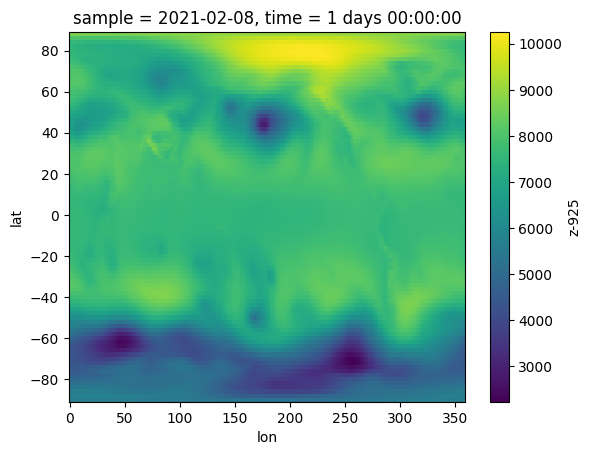

In [62]:
p = '/home/adboer/dlwp-benchmark/src/dlwpbench/outputs/PDErefhpx321241_60epoch_long/evaluation/targets.nc'
ds5= xr.open_dataset(p)
ds5['z-925'].isel(time=0).isel(sample=10).plot()

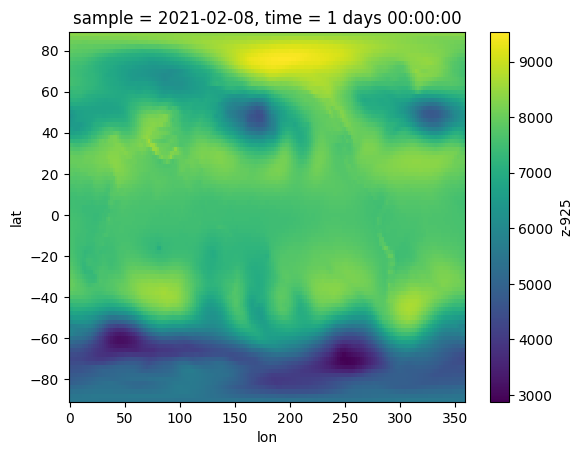

In [63]:
p = '/home/adboer/dlwp-benchmark/src/dlwpbench/scripts/helper_scripts/outputs_ensemble3_1.nc'
ds4 = xr.open_dataset(p)
ds4['z-925'].isel(time=0).isel(sample=10).plot()

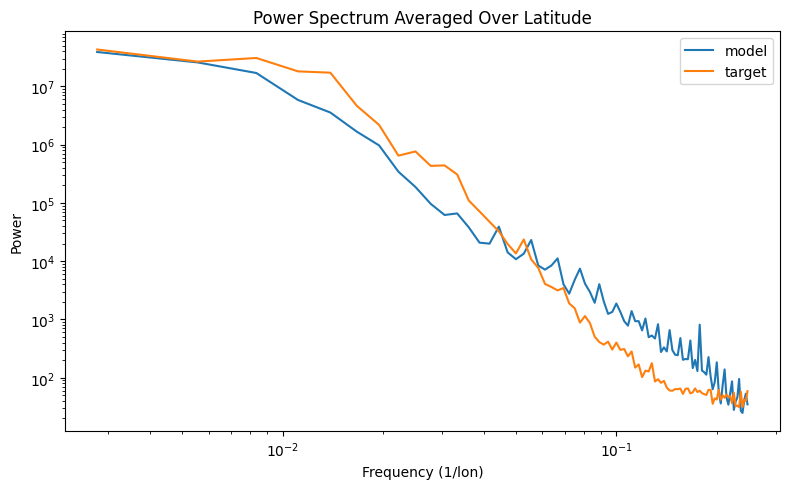

In [67]:
import xrft
import matplotlib.pyplot as plt

# Select the desired data slices
da4 = ds4['z-500'].isel(time=2, sample=10)
da5 = ds5['z-500'].isel(time=2, sample=10)

# Compute power spectra over longitude and average over latitude
power4 = xrft.power_spectrum(da4, dim='lon', scaling='density').mean(dim='lat')
power5 = xrft.power_spectrum(da5, dim='lon', scaling='density').mean(dim='lat')

# Select only positive frequencies
power4_pos = power4.where(power4['freq_lon'] > 0, drop=True)
power5_pos = power5.where(power5['freq_lon'] > 0, drop=True)

# Plot both on the same log-log plot
plt.figure(figsize=(8, 5))
plt.plot(power4_pos['freq_lon'], power4_pos, label='model')
plt.plot(power5_pos['freq_lon'], power5_pos, label='target')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency (1/lon)')
plt.ylabel('Power')
plt.title('Power Spectrum Averaged Over Latitude')
plt.legend()
plt.tight_layout()
plt.show()


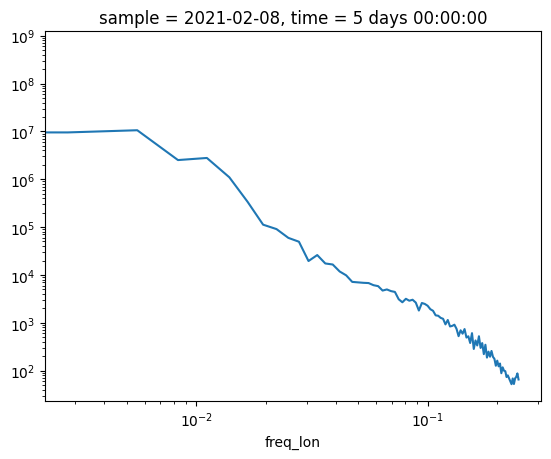

In [52]:
import xrft

# Select the desired data slice
da = ds4['z-1000'].isel(time=4, sample=10)
ds1 = ds5['z-1000'].isel(time=4, sample=10)
# Compute power spectrum over longitude
power = xrft.power_spectrum(da, dim='lon', scaling='density').mean(dim='lat')  # Use power_spectrum instead
# Plot magnitude (already real-valued from power_spectrum)
#power.plot(x='freq_lon') # only print positive values, use log log scale. 
# only print positive values, use log log scale. 
# Select only positive frequencies (assuming freq_lon is your frequency coordinate)

# Plot with log-log scale
power_pos.plot(x='freq_lon', yscale='log', xscale='log')




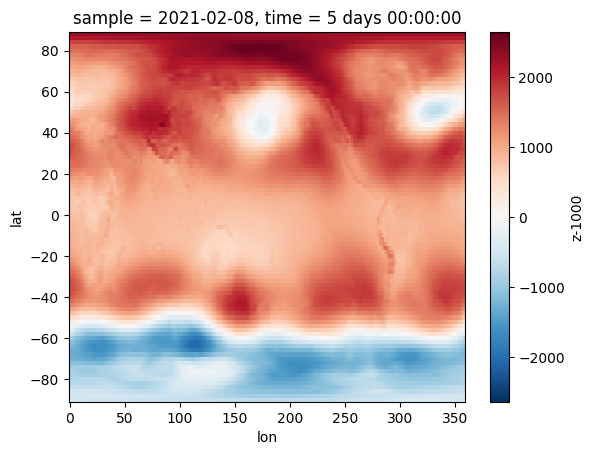

In [35]:
p = '/home/adboer/dlwp-benchmark/src/dlwpbench/scripts/helper_scripts/outputs_ensemble5_0.nc'
ds4 = xr.open_dataset(p)
ds4['z-1000'].isel(time=4).isel(sample=10).plot() # how to take the FFT over the longitude dimension such that we get power spectrum for each latitude?

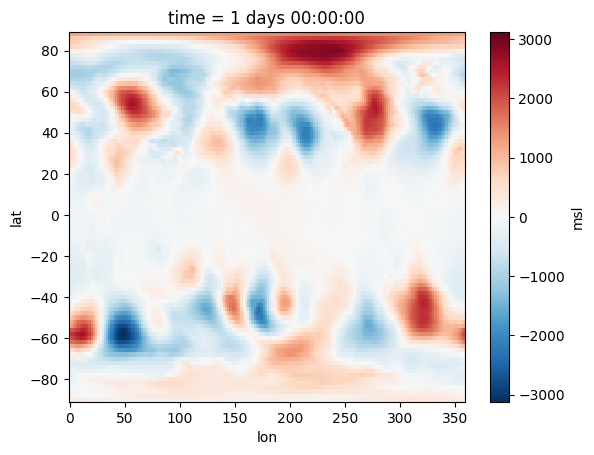

In [20]:
p = '/home/adboer/dlwp-benchmark/src/dlwpbench/outputs/PDErefhpx321240/evaluation/rmses_climatology.nc'
p = '/home/adboer/dlwp-benchmark/src/dlwpbench/outputs_ensemble5.nc'
ds3 = xr.open_dataset(p)
f = ds3[''].isel(time=0).isel(sample=10) - ds4['msl'].isel(time=0).isel(sample=9)
f.plot()

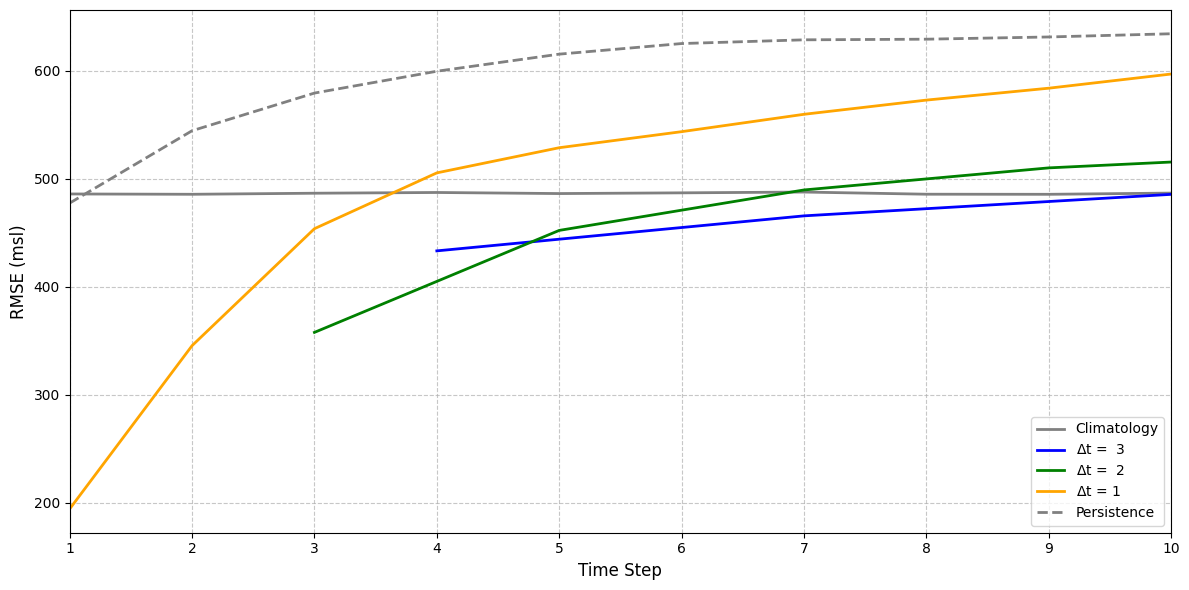

KeyError: "No variable named 'z-500z-100'. Variables on the dataset include ['time', 'msl', 'z-1000', 'z-925', 'z-850', ..., 'z-300', 'z-200', 'z-250', 'z-150', 'z-100']"

<Figure size 1200x600 with 0 Axes>

In [19]:
p_netcdf = f'/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses.nc'
ds11 = xr.open_dataset(p_netcdf)

p_netcdf = f'/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses_persistence.nc'
ds1 = xr.open_dataset(p_netcdf)

p_netcdf = f'/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses_climatology.nc'
ds2 = xr.open_dataset(p_netcdf)

p_netcdf = f'/projects/prjs1254/outputs/3daysteps/evaluation/rmses.nc'
ds3 = xr.open_dataset(p_netcdf)

p_netcdf = f'/projects/prjs1254/outputs/2daysteps/evaluation/rmses.nc'
ds22 = xr.open_dataset(p_netcdf)


climatology_ds = ds2 
persistence_ds = ds1 

# #Load data and stack into array
data = []

for var in  ['msl', 'z-500' 'z-100']:
    # make a column for each result

    # Create plot
    plt.figure(figsize=(12, 6))

    # Plot climatology
    plt.plot(climatology_ds[f'{var}'], color='grey', linewidth=2, label='Climatology')


    # Plot climatology
    plt.plot(range(3,15,3), ds3[f'{var}'], color='blue', linewidth=2, label= r'$\Delta$t =  3 ')
    plt.plot(range(2,20,2), ds22[f'{var}'].values, color='green', linewidth=2, label= r'$\Delta$t =  2 ')
    plt.plot(ds11[f'{var}'].values[:10], color='orange', linewidth=2, label=r'$\Delta$t = 1 ')
    # Plot persistence
    plt.plot( persistence_ds[f'{var}'], color='grey',linestyle = 'dashed', linewidth=2, label='Persistence')

    # Formatting
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel(f'RMSE ({var})', fontsize=12)
    #plt.title('RMSE Evolution Across Time Steps and Seeds', fontsize=14)
    plt.xticks( np.arange(0, 10, 1), np.arange(1, 11, 1))  # Show every 5th time step
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(0,9)
    plt.legend()
    plt.tight_layout()
    plt.show()

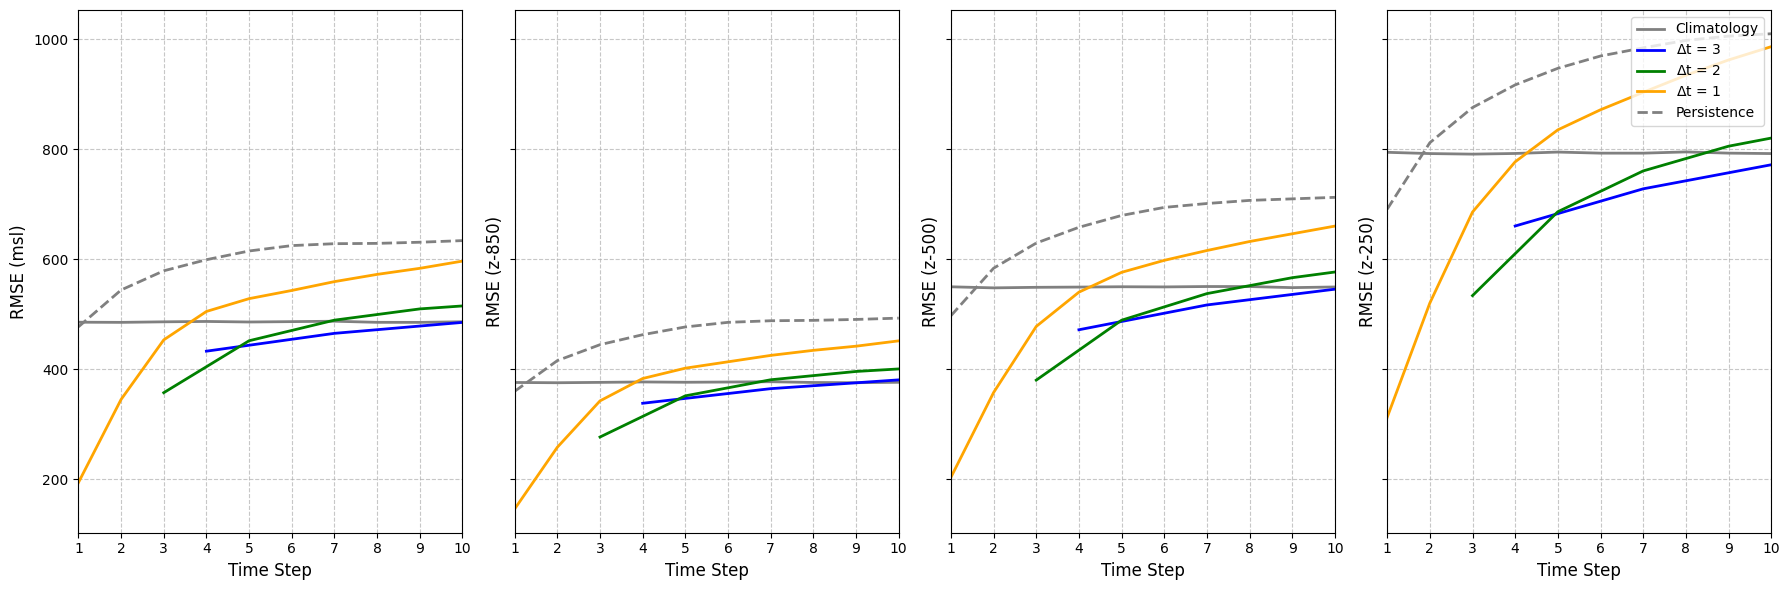

In [37]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Load datasets
ds11 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses.nc')
ds1 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses_persistence.nc')
ds2 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses_climatology.nc')
ds3 = xr.open_dataset('/projects/prjs1254/outputs/3daysteps/evaluation/rmses.nc')
ds22 = xr.open_dataset('/projects/prjs1254/outputs/2daysteps/evaluation/rmses.nc')

# Variables to plot
variables = ['msl', 'z-850','z-500', 'z-250']

# Create subplots: 1 row x 3 columns
fig, axes = plt.subplots(1, len(variables), figsize=(18, 6), sharey=True)

for i, var in enumerate(variables):
    ax = axes[i]
    
    # Plot climatology
    ax.plot(ds2[f'{var}'], color='grey', linewidth=2, label='Climatology')

    # Plot models with different timesteps
    ax.plot(range(3, 15, 3), ds3[f'{var}'], color='blue', linewidth=2, label=r'$\Delta$t = 3')
    ax.plot(range(2, 20, 2), ds22[f'{var}'].values, color='green', linewidth=2, label=r'$\Delta$t = 2')
    ax.plot(ds11[f'{var}'].values[:10], color='orange', linewidth=2, label=r'$\Delta$t = 1')

    # Plot persistence
    ax.plot(ds1[f'{var}'], color='grey', linestyle='dashed', linewidth=2, label='Persistence')

    # Formatting
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel(f'RMSE ({var})', fontsize=12)
    ax.set_xticks(np.arange(0, 10, 1))
    ax.set_xticklabels(np.arange(1, 11, 1))  # Time steps start from 1
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlim(0, 9)
    
    # Add legend only to the last subplot for clarity (optional)
    if i == len(variables) - 1:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (10,) and arg 1 with shape (4,).

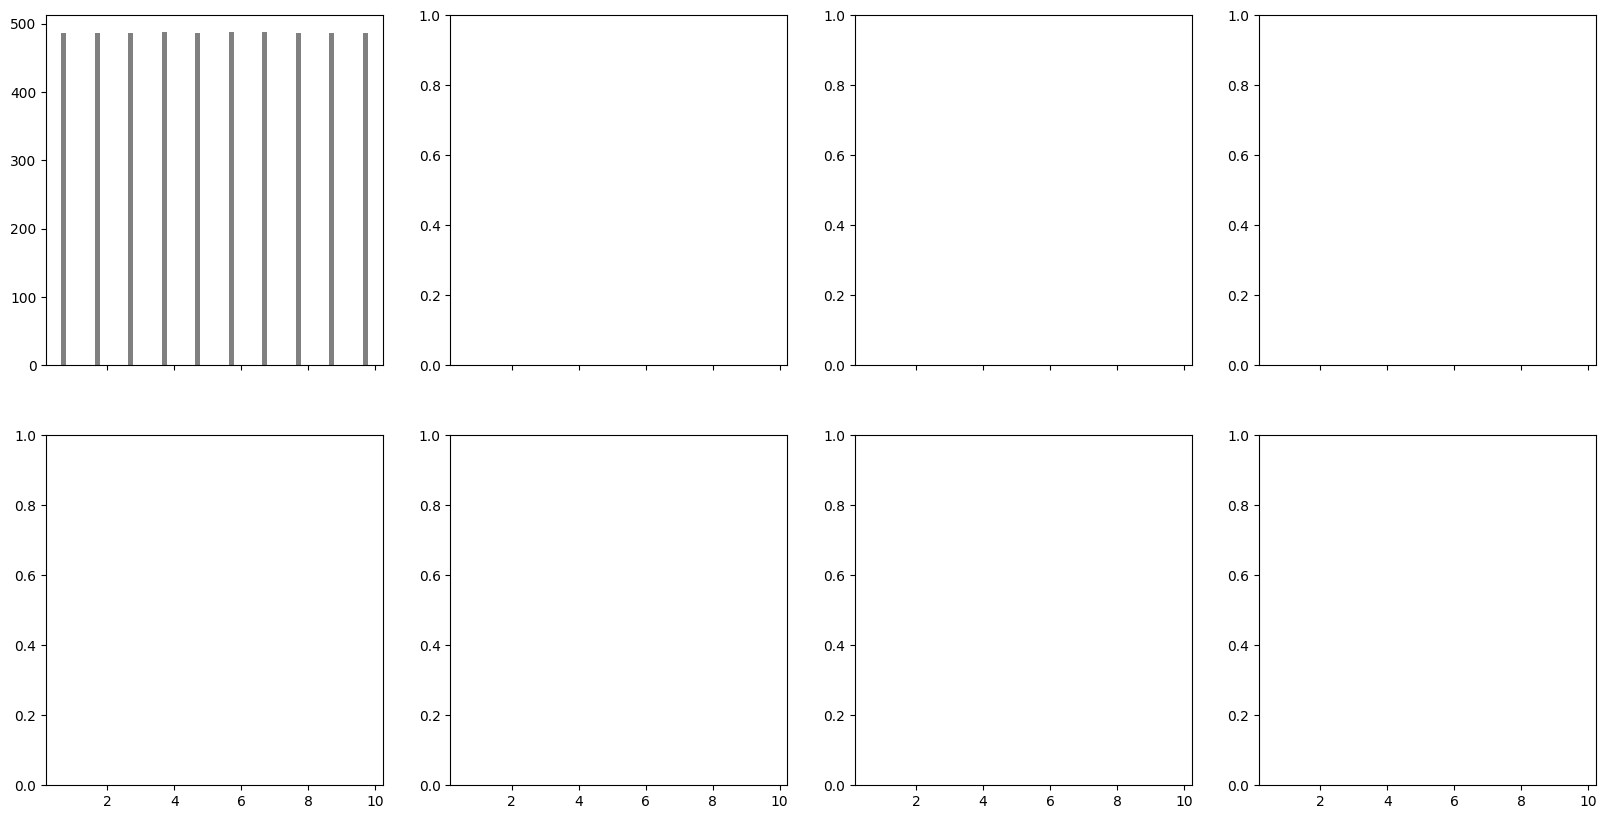

In [33]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Load RMSE datasets
ds11 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses.nc')
ds1 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses_persistence.nc')
ds2 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses_climatology.nc')
ds3 = xr.open_dataset('/projects/prjs1254/outputs/3daysteps/evaluation/rmses.nc')
ds22 = xr.open_dataset('/projects/prjs1254/outputs/2daysteps/evaluation/rmses.nc')

# Load ACC datasets
acc_ds11 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/accs.nc')
acc_ds3 = xr.open_dataset('/projects/prjs1254/outputs/3daysteps/evaluation/accs.nc')
acc_ds22 = xr.open_dataset('/projects/prjs1254/outputs/2daysteps/evaluation/accs.nc')

# Variables to plot
variables = ['msl', 'z-850', 'z-500', 'z-250']

# Create subplots: 2 rows (RMSE and ACC) x 4 columns (variables)
fig, axes = plt.subplots(2, len(variables), figsize=(20, 10), sharex=True)

# Plot RMSE (row 1)
for i, var in enumerate(variables):
    ax = axes[0, i]
    
    # Data for bar chart
    time_steps = np.arange(1, 11)  # Example time steps
    rmse_climatology = ds2[f'{var}'].values[:10]
    rmse_t3 = ds3[f'{var}'].values[:10]
    rmse_t2 = ds22[f'{var}'].values[:10]
    rmse_t1 = ds11[f'{var}'].values[:10]
    rmse_persistence = ds1[f'{var}'].values[:10]

    # Bar width and positions
    bar_width = 0.15
    positions = time_steps - bar_width * 2

    # Plot bars for each model
    ax.bar(positions, rmse_climatology, width=bar_width, color='grey', label='Climatology')
    ax.bar(positions + bar_width, rmse_t3, width=bar_width, color='blue', label=r'$\Delta$t = 3')
    ax.bar(positions + 2 * bar_width, rmse_t2, width=bar_width, color='green', label=r'$\Delta$t = 2')
    ax.bar(positions + 3 * bar_width, rmse_t1, width=bar_width, color='orange', label=r'$\Delta$t = 1')
    ax.bar(positions + 4 * bar_width, rmse_persistence, width=bar_width, color='grey', alpha=0.5, label='Persistence')

    # Formatting
    ax.set_title(f'{var}')
    ax.set_ylabel('RMSE', fontsize=12)
    ax.set_xticks(time_steps)
    ax.set_xticklabels(time_steps)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Add legend to the last subplot (optional)
    if i == len(variables) - 1:
        ax.legend(loc='upper right')

# Plot ACC (row 2)
for i, var in enumerate(variables):
    ax = axes[1, i]
    
    # Data for bar chart
    acc_t3 = acc_ds3[f'{var}'].values[:10]
    acc_t2 = acc_ds22[f'{var}'].values[:10]
    acc_t1 = acc_ds11[f'{var}'].values[:10]

    # Plot bars for each model
    ax.bar(positions + bar_width, acc_t3, width=bar_width, color='blue', label=r'$\Delta$t = 3')
    ax.bar(positions + 2 * bar_width, acc_t2, width=bar_width, color='green', label=r'$\Delta$t = 2')
    ax.bar(positions + 3 * bar_width, acc_t1, width=bar_width, color='orange', label=r'$\Delta$t = 1')

    # Formatting
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel('ACC', fontsize=12)
    ax.set_xticks(time_steps)
    ax.set_xticklabels(time_steps)
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Add legend to the last subplot (optional)
    if i == len(variables) - 1:
        ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


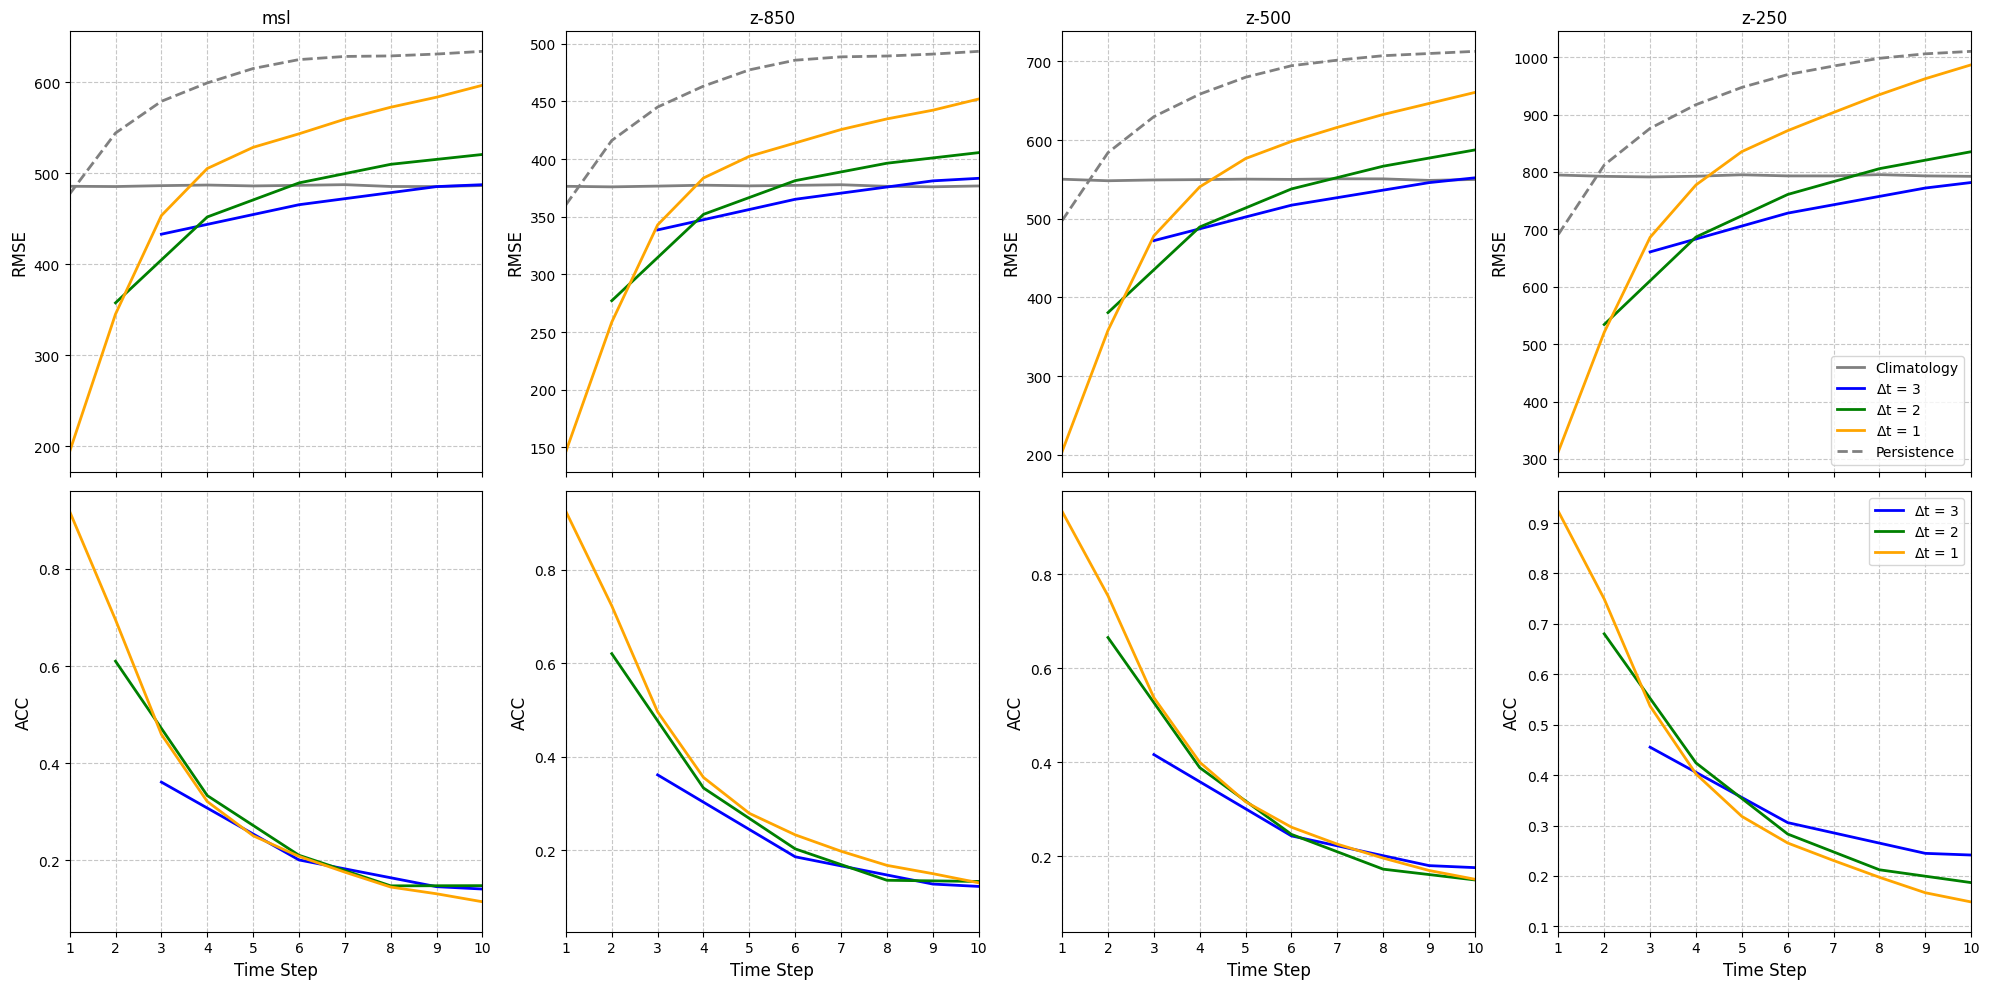

In [32]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

# Load RMSE datasets
ds11 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses.nc')
ds1 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses_persistence.nc')
ds2 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/rmses_climatology.nc')
ds3 = xr.open_dataset('/projects/prjs1254/outputs/3daysteps/evaluation/rmses.nc')
ds22 = xr.open_dataset('/projects/prjs1254/outputs/2daysteps/evaluation/rmses.nc')

# Load ACC datasets
acc_ds11 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/accs.nc')
#acc_ds1 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/accs_persistence.nc')
#acc_ds2 = xr.open_dataset('/projects/prjs1254/outputs/UNETHPX32/PDErefhpx321241/evaluation/accs_climatology.nc')
acc_ds3 = xr.open_dataset('/projects/prjs1254/outputs/3daysteps/evaluation/accs.nc')
acc_ds22 = xr.open_dataset('/projects/prjs1254/outputs/2daysteps/evaluation/accs.nc')

# Variables to plot
variables = ['msl', 'z-850', 'z-500', 'z-250']

# Create subplots: 2 rows (RMSE and ACC) x 4 columns (variables)
fig, axes = plt.subplots(2, len(variables), figsize=(20, 10), sharex=True)

# Plot RMSE (row 1)
for i, var in enumerate(variables):
    ax = axes[0, i]
    
    # Plot climatology
    ax.set_title(f'{var}')
    ax.plot(ds2[f'{var}'], color='grey', linewidth=2, label='Climatology')

    # Plot models with different timesteps
    ax.plot(range(2, 14, 3), ds3[f'{var}'], color='blue', linewidth=2, label=r'$\Delta$t = 3')
    ax.plot(range(1, 19, 2), ds22[f'{var}'].values, color='green', linewidth=2, label=r'$\Delta$t = 2')
    ax.plot(ds11[f'{var}'].values[:10], color='orange', linewidth=2, label=r'$\Delta$t = 1')

    # Plot persistence
    ax.plot(ds1[f'{var}'], color='grey', linestyle='dashed', linewidth=2, label='Persistence')

    # Formatting
    #ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel(f'RMSE', fontsize=12)
    ax.set_xticks(np.arange(0, 10, 1))
    ax.set_xticklabels(np.arange(1, 11, 1))  # Time steps start from 1
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlim(0, 9)
    
    # Add legend only to the last subplot for clarity (optional)
    if i == len(variables) - 1:
        ax.legend(loc='lower right')

# Plot ACC (row 2)
for i, var in enumerate(variables):
    ax = axes[1, i]
    
    # Plot climatology
    #ax.plot(acc_ds2[f'{var}'], color='grey', linewidth=2, label='Climatology')

    # Plot models with different timesteps
    ax.plot(range(2, 14, 3), acc_ds3[f'{var}'], color='blue', linewidth=2, label=r'$\Delta$t = 3')
    ax.plot(range(1, 19, 2), acc_ds22[f'{var}'].values, color='green', linewidth=2, label=r'$\Delta$t = 2')
    ax.plot(acc_ds11[f'{var}'].values[:10], color='orange', linewidth=2, label=r'$\Delta$t = 1')

    # Plot persistence
    #ax.plot(acc_ds1[f'{var}'], color='grey', linestyle='dashed', linewidth=2, label='Persistence')

    # Formatting
    ax.set_xlabel('Time Step', fontsize=12)
    ax.set_ylabel(f'ACC', fontsize=12)
    ax.set_xticks(np.arange(0, 10, 1))
    ax.set_xticklabels(np.arange(1, 11, 1))  # Time steps start from 1
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlim(0, 9)
    
    # Add legend only to the last subplot for clarity (optional)
    if i == len(variables) - 1:
        ax.legend(loc='upper right')


plt.tight_layout()
plt.show()


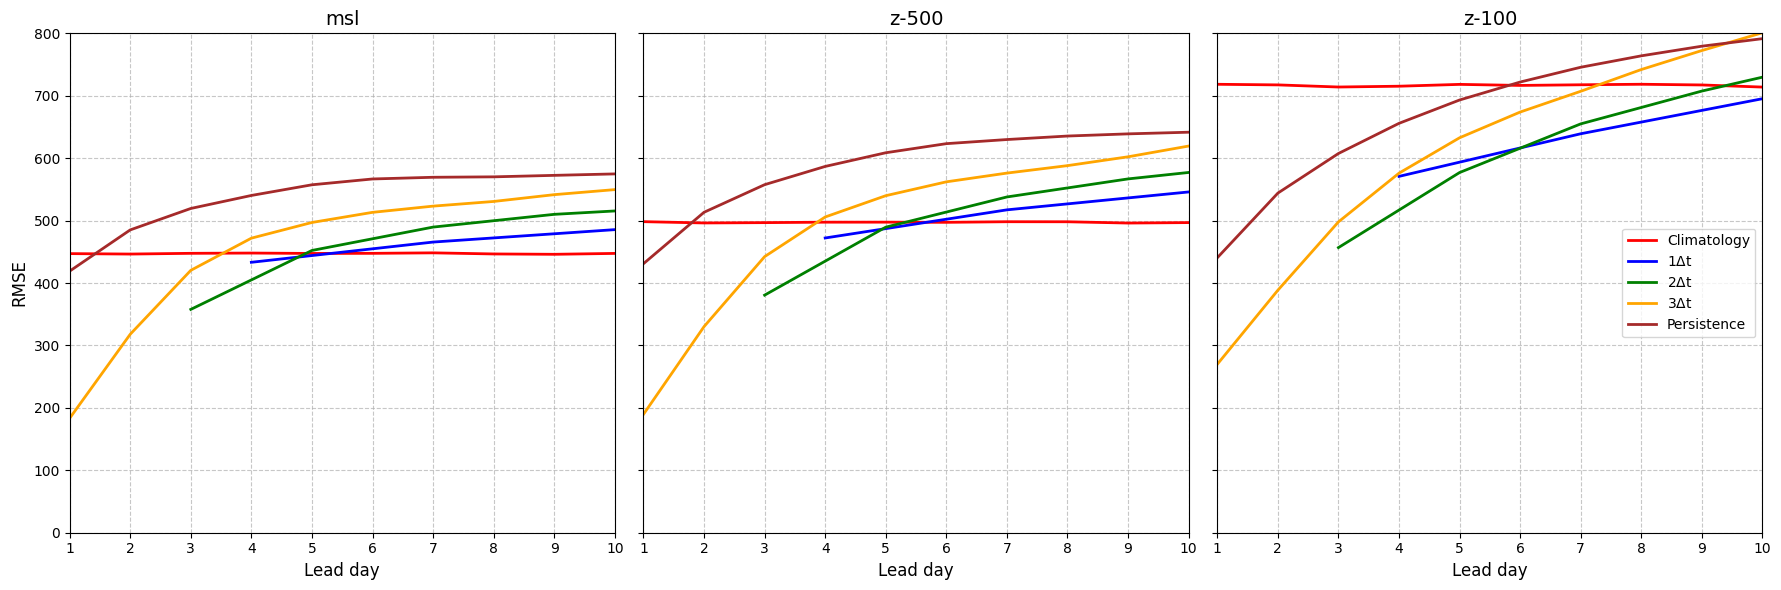

In [46]:
import matplotlib.pyplot as plt
import numpy as np

# List of variables to plot
variables = ['msl', 'z-500', 'z-100']

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 3, figsize=(18, 6),sharey=True)  # Share y-axis for comparison

for i, var in enumerate(variables):
    ax = axes[i]  # Select the appropriate subplot
    
    # Plot climatology
    ax.plot(climatology_ds[f'{var}'], color='red', linewidth=2, label='Climatology')

    # Plot results with different step sizes
    ax.plot(range(3, 15, 3), ds3[f'{var}'], color='blue', linewidth=2, label=r'1$\Delta$t ')
    ax.plot(range(2, 20, 2), ds22[f'{var}'].values, color='green', linewidth=2, label=r'2$\Delta$t')
    ax.plot(ds11[f'{var}'].values[:10], color='orange', linewidth=2, label=r'$3\Delta$t')

    # Plot persistence
    ax.plot(persistence_ds[f'{var}'], color='brown', linewidth=2, label='Persistence')

    # Formatting for each subplot
    ax.set_xlabel('Lead day', fontsize=12)
    if i == 0:  # Add y-axis label only to the first subplot
        ax.set_ylabel(f'RMSE', fontsize=12)
    ax.set_title(f'{var}', fontsize=14)
    ax.set_xticks(np.arange(0, 10, 1))  # Adjust x-axis ticks
    ax.set_xticklabels(np.arange(1, 11, 1))  # Show time steps starting from 1
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.set_xlim(0, 9)  # Limit x-axis range
    
    # Add legend to the first column only (to avoid repetition)
    if i == len(variables) - 1:
        ax.legend(loc='right')

# Adjust layout and display the figure
plt.tight_layout()
plt.ylim(0,800)
plt.show()
